# Multi-Model AutoML LOOCV Pipeline — SC node strength, ROI 4개 (pass)

- **Clinical_ONLY**: `vas_t0`, `treatment_group` (2개)
- **Brain_Plus_Clinical**: 위 2개 + SC node strength 4개 (Residualized)
- **제거 변수**: age, sex, **eTIV** / **타겟**: vas_t1 / **n = 44** (FC와 같은 표본, rid=1 제외)
- **연결 기준**: **pass** — streamline이 두 영역을 모두 지나가면 연결로 센다 (DSI Studio 기본값). **주 분석**

같은 이름의 FC 노트북과 **파이프라인이 같다**. 모델 6개, LOOCV, fold 안에서의 nuisance 잔차화,
내부 GridSearchCV(cv=3)를 그대로 두고 뇌 피처만 SC로 바꿨다.

ROI 4개는 FC 노트북과 같다: `lh_medialorbitofrontal`, `rh_caudalanteriorcingulate`, `lh_bankssts`, `rh_lateralorbitofrontal`.
이 영역들은 FC 선행연구(Nature Mental Health 2024)에서 왔다. SC 근거로 고른 것이 아니다.

## FC 노트북과 달라진 점

| | FC | 이 노트북 |
|---|---|---|
| 데이터 | `fc_strength_68_16.csv` / `fc_full_84x84_edited.csv` | `sc_strength_84_pass.csv` / `sc_full_84x84_pass.csv` |
| 값 | Fisher z | streamline 개수(count)에 **log(1 + count)** |
| n | 44 | **44** (SC는 sub-001도 있지만 FC와 맞추려고 뺐다) |
| 교란변수 | age, sex, mean_fd | age, sex, **eTIV** |
| 뇌 피처 | strength 4개 | 같은 개수 |

- **log(1 + count)**: streamline 수는 몇 개~수만 개로 치우쳐 있다. SC 값 자체를 피처로 쓸 때는 log로 편다 (Tong 2026).
  strength는 행을 **더한 뒤** log를 씌운다.
- **eTIV**: SC strength는 뇌와 영역이 클수록 커진다. mean_fd는 fMRI 촬영 중 움직임이라 SC와 무관하다.
- **n**: SC 파일에는 45명이 있다. sub-001은 ses-t0 FC가 없어 FC 분석에 빠져 있으므로, 여기서도 빼서 같은 44명으로 맞춘다.
- **nuisance 표준화**: 잔차화 직전에 age, sex, eTIV를 train 기준으로 표준화한다. 잔차는 수학적으로 같다.
  eTIV가 백만 단위 숫자 그대로 들어가면, 피처 수가 인원보다 많을 때 LinearRegression의 계산이 깨져
  RMSE가 수십억으로 나온다 (계산 정밀도 문제). FC는 mean_fd가 작은 수라 이 단계가 없어도 됐다.

## 연결 기준 두 가지

SC는 "무엇을 연결로 세느냐"에 따라 값이 크게 달라진다. 그래서 같은 분석을 두 기준으로 따로 만들었다
(`..._pass.ipynb`, `..._end.ipynb`).

| | pass | end |
|---|---|---|
| 세는 방식 | 지나가기만 해도 셈 | 양 끝점이 영역 안일 때만 |
| 행렬 합 평균 | 1,340,876 | 124,455 |
| 밀도 | 0.645 | 0.418 |

**주 분석은 pass, end는 민감도 분석**으로 결과를 보기 전에 정해 두었다. 어느 쪽이 좋게 나오든 둘 다 보고한다.
pass는 streamline 하나가 여러 쌍에 중복으로 들어간다는 비판이 있고(Yeh 2021), end는 피질 라벨에 못 미쳐 멈춘
streamline을 버린다.


In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (SC node strength)
# ==========================================================
SC_RULE = 'pass'           # 'pass'(지나가면 셈, 주 분석) 또는 'end'(끝점 기준, 민감도 분석)
df = pd.read_csv(f'sc_strength_84_{SC_RULE}.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()
# FC(44명)와 표본을 맞춘다. sub-001은 ses-t0 FC가 없어 FC 분석에 빠져 있다.
df = df[df['rid'] != 1].reset_index(drop=True)

# FC 노트북과 같은 4개 영역 (schaefer_to_dk_mapping.ipynb 결과). 영역은 FC 선행연구에서 왔고,
# 여기서는 같은 영역의 SC strength를 본다.
#   OFC 2개  : 논문의 LIM OFC 좌/우. 최근접 DK만 채택 (lh medial / rh lateral)
#   rh_caudalanteriorcingulate : 논문의 RH Cont PFCmp 2 (8.2mm, 단일 후보 뚜렷)
#   lh_bankssts                : 논문의 LH DMN Temp 3 (9.4mm, 단일 후보 뚜렷)
brain_regions = [
    'lh_medialorbitofrontal',
    'rh_caudalanteriorcingulate',
    'lh_bankssts',
    'rh_lateralorbitofrontal'
]

# strength 컬럼은 {region}_sc 형식
brain_features = [f'{r}_sc' for r in brain_regions]
missing = [c for c in brain_features if c not in df.columns]
assert not missing, f'컬럼 없음: {missing}'

nuisance_covariates = ['age', 'sex', 'eTIV']       # SC strength는 뇌 크기를 따라간다 (mean_fd는 fMRI 움직임이라 무관)
clinical_predictors = ['vas_t0', 'treatment_group']
target = 'vas_t1'

# SC는 streamline 개수라 치우쳐 있다. 피처로 쓸 때는 log(1 + count)로 편다 (Tong 2026).
X_brain = np.log1p(df[brain_features].values)
X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values

print(f'n = {len(df)},  brain features = {X_brain.shape[1]}')
print(brain_features)


n = 44,  brain features = 4
['lh_medialorbitofrontal_sc', 'rh_caudalanteriorcingulate_sc', 'lh_bankssts_sc', 'rh_lateralorbitofrontal_sc']


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP
# ==========================================================
# [변경] Baseline 항목 삭제. 모든 모델이 두 데이터셋에 동일하게 적용됨.
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],   # 위로 확장
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]    # 아래로 확장
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]                # 위로
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로 (최우선)
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],        # 아래로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]                        # split보다 leaf가 n작을 때 효과적
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],                                 # n=45면 5는 과함
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]                                # 규제 추가
    },
}

DATA_TYPES = ['Clinical_ONLY', 'Brain_Plus_Clinical']

In [4]:
X_brain.shape

(44, 4)

In [5]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
# ==========================================================
loo = LeaveOneOut()
# [변경] 예측을 (데이터셋, 모델) 조합별로 저장
predictions = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_brain)):
    print(f"Processing fold {fold_idx+1}/{len(y)}...", end='\r')

    X_b_train, X_b_test = X_brain[train_idx], X_brain[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Nuisance Residualization ---
    # nuisance를 표준화한 뒤 잔차화한다. 잔차는 수학적으로 같지만, eTIV(백만 단위)가 그대로 들어가면
    # 피처 수 > 인원일 때 LinearRegression 계산이 깨진다 (RMSE가 수십억으로 나옴).
    nz = StandardScaler().fit(X_n_train)               # 평균·표준편차는 train에서만
    X_n_train, X_n_test = nz.transform(X_n_train), nz.transform(X_n_test)
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_b_train)
    X_b_train_clean = X_b_train - nuisance_regressor.predict(X_n_train)
    X_b_test_clean = X_b_test - nuisance_regressor.predict(X_n_test)

    # --- Features Stack ---
    X_train_full = np.hstack([X_b_train_clean, X_c_train]) # brain 4개 + clinical 2
    X_test_full = np.hstack([X_b_test_clean, X_c_test])

    y_true.append(y_test[0])

    # [변경] 두 데이터셋을 딕셔너리로 묶어 동일하게 처리
    raw_sets = {
        'Clinical_ONLY': (X_c_train, X_c_test),
        'Brain_Plus_Clinical': (X_train_full, X_test_full),
    }

    for dt, (X_tr_raw, X_te_raw) in raw_sets.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
        X_te = scaler.transform(X_te_raw)

        for name, model in models.items():
            inner_cv = GridSearchCV(model, param_grids[name], cv=3, # nested CV 최적은 결국 mse 기준으로 선택됨
                                    scoring='neg_mean_squared_error', n_jobs=1)
            inner_cv.fit(X_tr, y_train) 
            pred = inner_cv.best_estimator_.predict(X_te) # 외부 테스트
            predictions[(dt, name)].append(pred[0]) # 예측값 저장
            best_params_log[(dt, name)].append(str(inner_cv.best_params_))

print("\n\nLOOCV Completed.")

Starting LOOCV: 6 models x 2 datasets...





LOOCV Completed.


In [6]:
# ==========================================================
# 4. EVALUATION & PAIRED COMPARISON
# ==========================================================
y_true = np.array(y_true)

results = []
for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)
    corr, p_val = pearsonr(y_true, y_pred)
    results.append({
        'Data Type': dt,
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred),
        'Pearson (r)': corr,
        'p-value': p_val,
    })
    

results_df = pd.DataFrame(results)

# --- 기준선: 평균만 예측하는 모델 ---
baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델의 LOOCV RMSE = {baseline_rmse:.3f}")
print("  -> 이 값보다 나쁜 모델은 예측력이 없는 것임\n")

# --- Paired 표 (행 = 모델, 열 = 데이터셋) ---
pivot = results_df.pivot(index='Model', columns='Data Type', values='RMSE')
pivot['dRMSE'] = pivot['Clinical_ONLY'] - pivot['Brain_Plus_Clinical']
pivot = pivot.sort_index()   # dRMSE 정렬 안 함

n_pos = int((pivot['dRMSE'] > 0).sum())  
n_tot = len(pivot)

print("========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========")
display(pivot)

print(f"\n부호 일관성: {n_tot}개 중 {n_pos}개가 +")
if n_pos == n_tot:
    print("  -> 전부 +. 알고리즘 선택과 무관하게 개선.")
elif n_pos == 0:
    print("  -> 전부 -. 뇌 지표가 오히려 해가 됨.")
else:
    print("  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.")
    print("  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== 전체 지표 ==========")
display(results_df.sort_values(['Model', 'Data Type']))

평균만 예측하는 모델의 LOOCV RMSE = 2.309
  -> 이 값보다 나쁜 모델은 예측력이 없는 것임

========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========


Data Type,Brain_Plus_Clinical,Clinical_ONLY,dRMSE
Model,,,
ElasticNet,2.160437,1.996230,-0.164207
LinearRegression,2.141147,1.997338,-0.143810
RandomForest,2.304575,2.200693,-0.103881
SVR_Linear,2.047057,2.040615,-0.006442
SVR_RBF,2.127358,2.208213,0.080855
XGBoost,2.397346,2.235297,-0.162050



부호 일관성: 6개 중 1개가 +
  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.
  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.

========== 전체 지표 ==========


,Data Type,Model,RMSE,R2 Score,Pearson (r),p-value
7,Brain_Plus_Clinical,ElasticNet,2.160437,0.083592,0.325625,0.031011
1,Clinical_ONLY,ElasticNet,1.996230,0.217604,0.477844,0.001037
6,Brain_Plus_Clinical,LinearRegression,2.141147,0.099884,0.387666,0.009322
0,Clinical_ONLY,LinearRegression,1.997338,0.216736,0.478364,0.001022
10,Brain_Plus_Clinical,RandomForest,2.304575,-0.042766,0.250699,0.100714
4,Clinical_ONLY,RandomForest,2.200693,0.049123,0.327847,0.029816
8,Brain_Plus_Clinical,SVR_Linear,2.047057,0.177255,0.444957,0.002475
2,Clinical_ONLY,SVR_Linear,2.040615,0.182425,0.449354,0.002214
9,Brain_Plus_Clinical,SVR_RBF,2.127358,0.111440,0.382007,0.010501
3,Clinical_ONLY,SVR_RBF,2.208213,0.042613,0.347018,0.021009


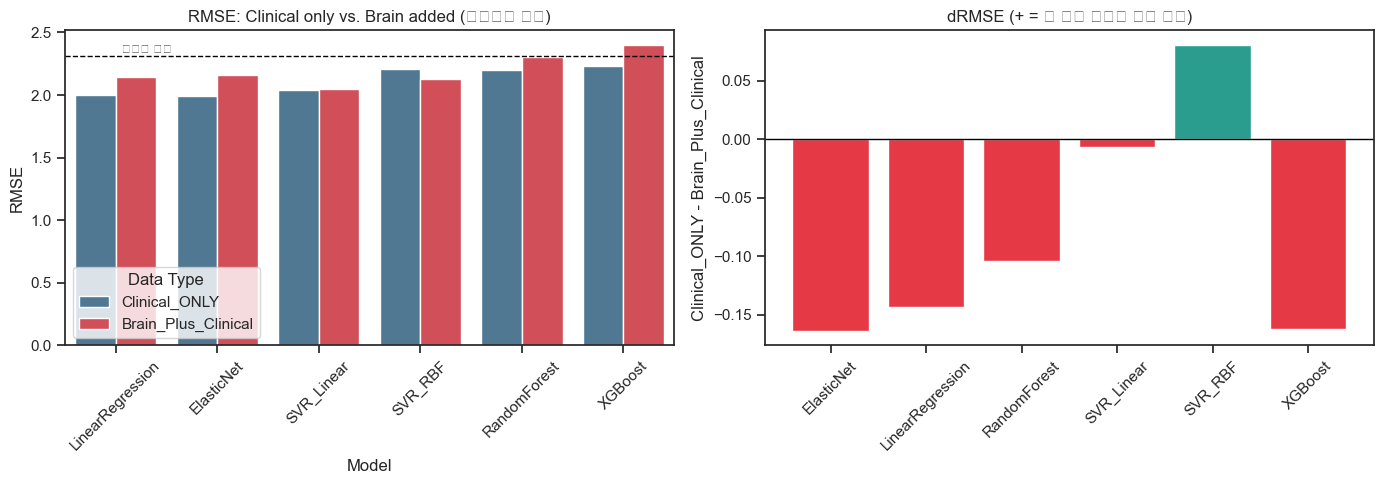

In [7]:
# ==========================================================
# 5. VISUALIZATION (Paired)
# ==========================================================
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 모델별 RMSE를 데이터셋으로 나눠 나란히
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Data Type',
            palette=['#457B9D', '#E63946'], ax=axes[0])
axes[0].axhline(baseline_rmse, color='black', linestyle='--', linewidth=1)
axes[0].text(0.02, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
axes[0].set_title('RMSE: Clinical only vs. Brain added (낮을수록 좋음)')
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: dRMSE
colors = ['#2A9D8F' if v > 0 else '#E63946' for v in pivot['dRMSE']]
axes[1].bar(pivot.index, pivot['dRMSE'], color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('dRMSE (+ = 뇌 지표 추가로 오차 감소)')
axes[1].set_ylabel('Clinical_ONLY - Brain_Plus_Clinical')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 6. 하이퍼파라미터 안정성 (선택 사항)
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{name} / {dt}] 고유 조합 {len(vc)}개, 최빈 {share:.0%}{flag}")

[LinearRegression / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[ElasticNet / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[SVR_Linear / Clinical_ONLY] 고유 조합 12개, 최빈 43%   <-- 불안정
[SVR_RBF / Clinical_ONLY] 고유 조합 7개, 최빈 84%
[RandomForest / Clinical_ONLY] 고유 조합 5개, 최빈 61%
[XGBoost / Clinical_ONLY] 고유 조합 4개, 최빈 86%
[LinearRegression / Brain_Plus_Clinical] 고유 조합 1개, 최빈 100%
[ElasticNet / Brain_Plus_Clinical] 고유 조합 5개, 최빈 59%
[SVR_Linear / Brain_Plus_Clinical] 고유 조합 15개, 최빈 18%   <-- 불안정
[SVR_RBF / Brain_Plus_Clinical] 고유 조합 7개, 최빈 43%   <-- 불안정
[RandomForest / Brain_Plus_Clinical] 고유 조합 5개, 최빈 50%
[XGBoost / Brain_Plus_Clinical] 고유 조합 3개, 최빈 55%


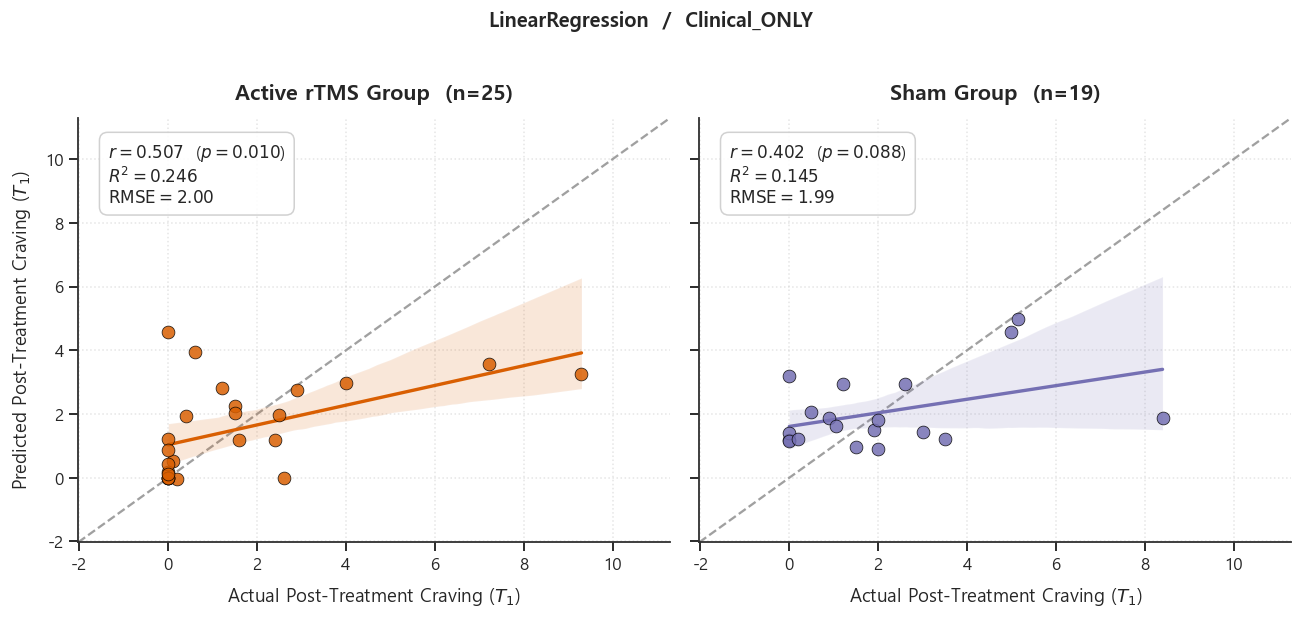

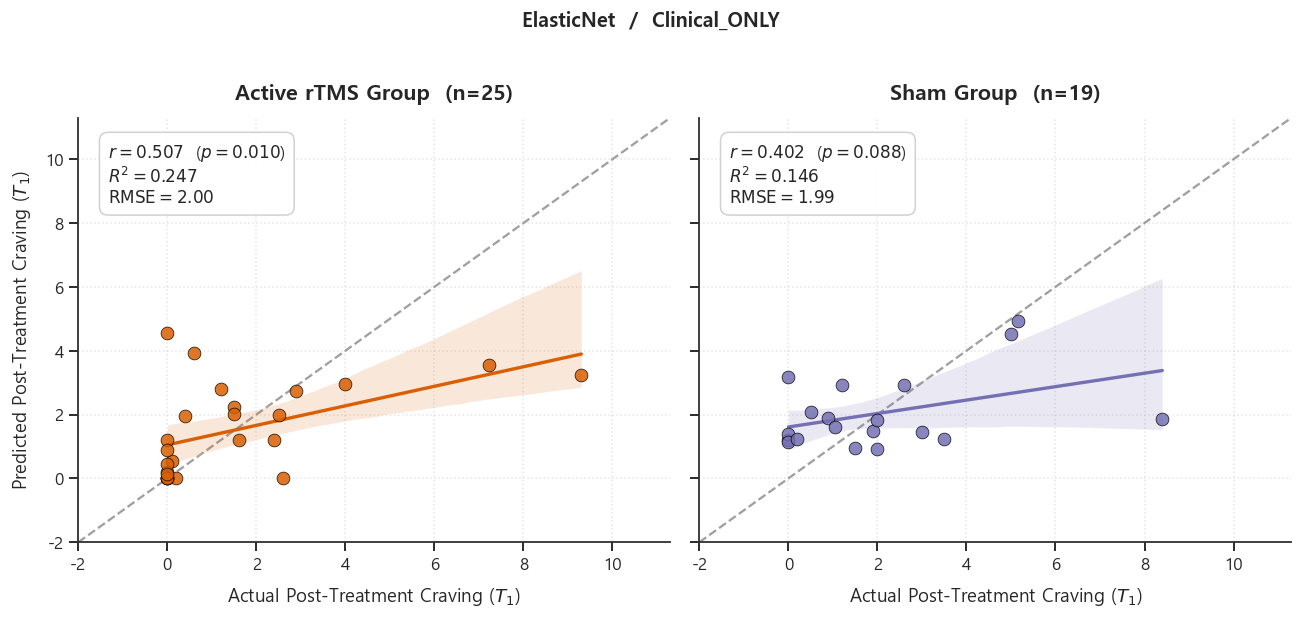

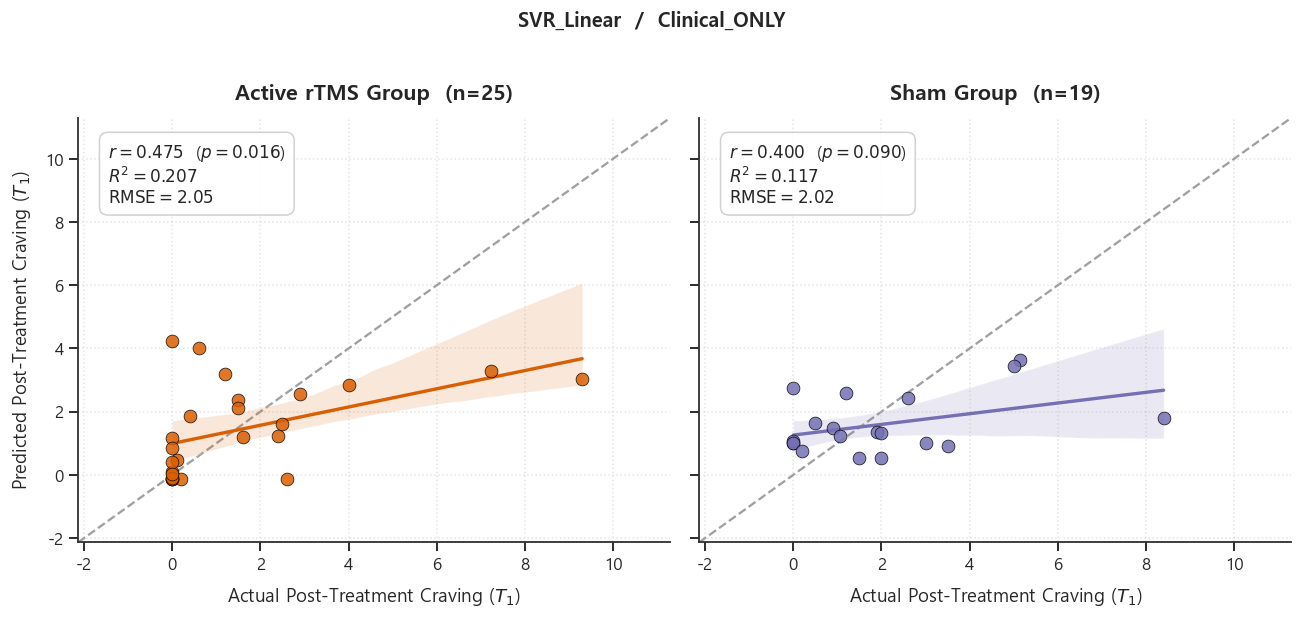

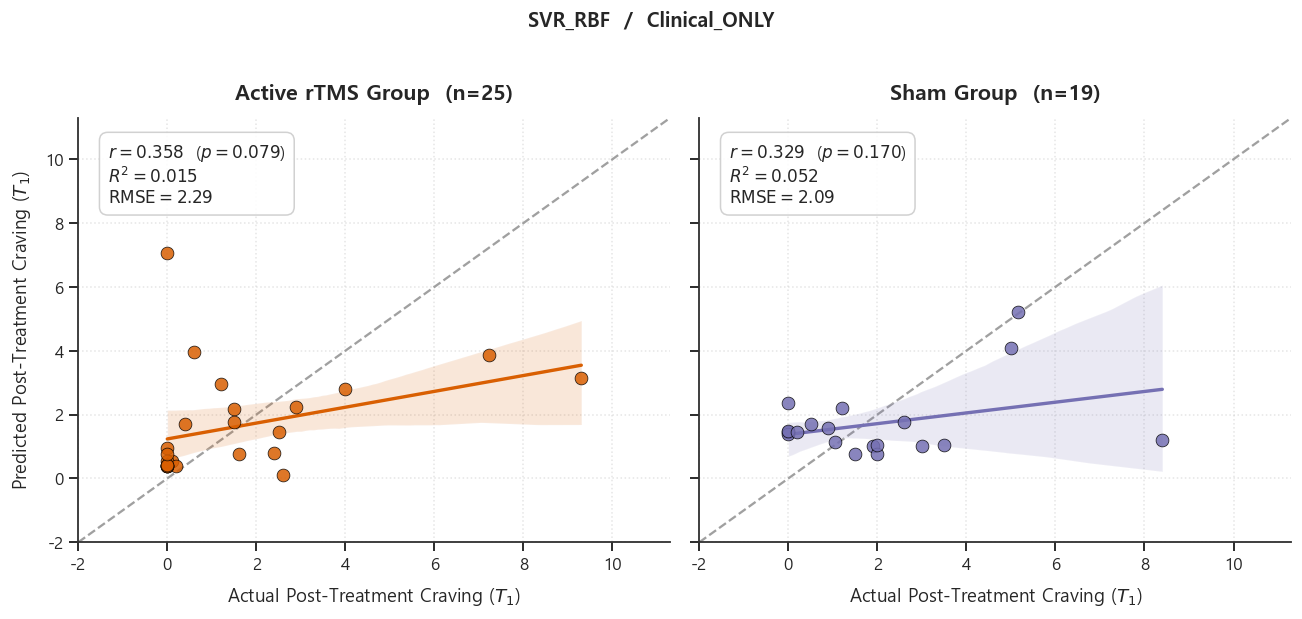

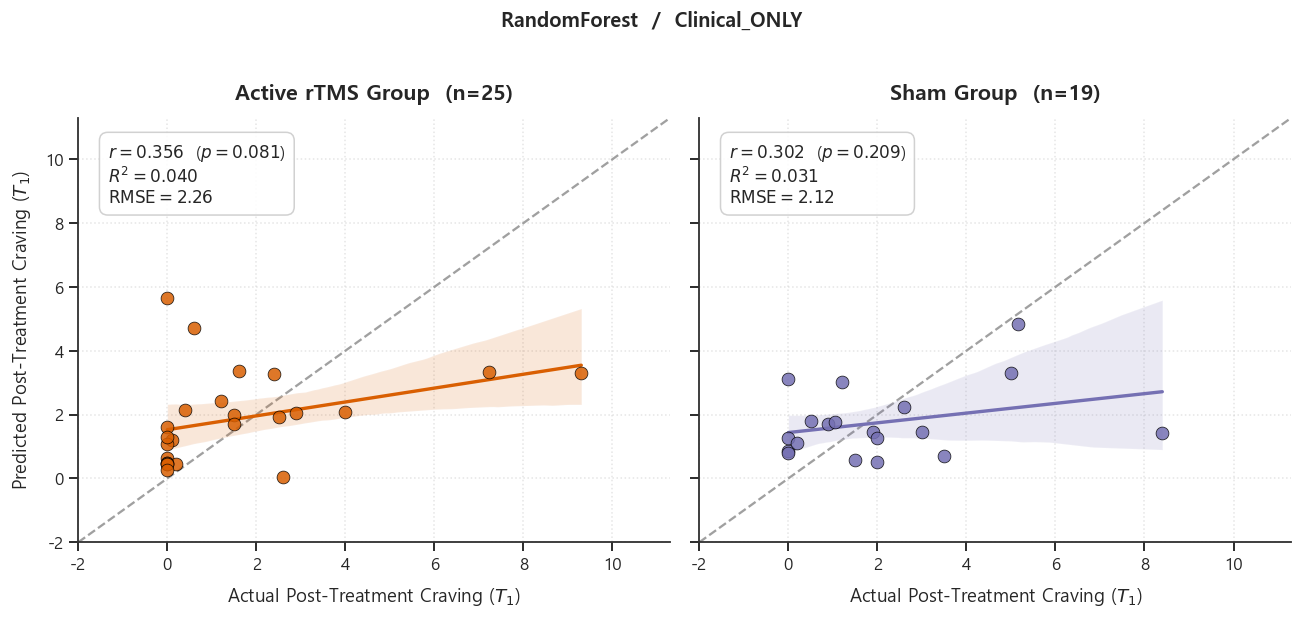

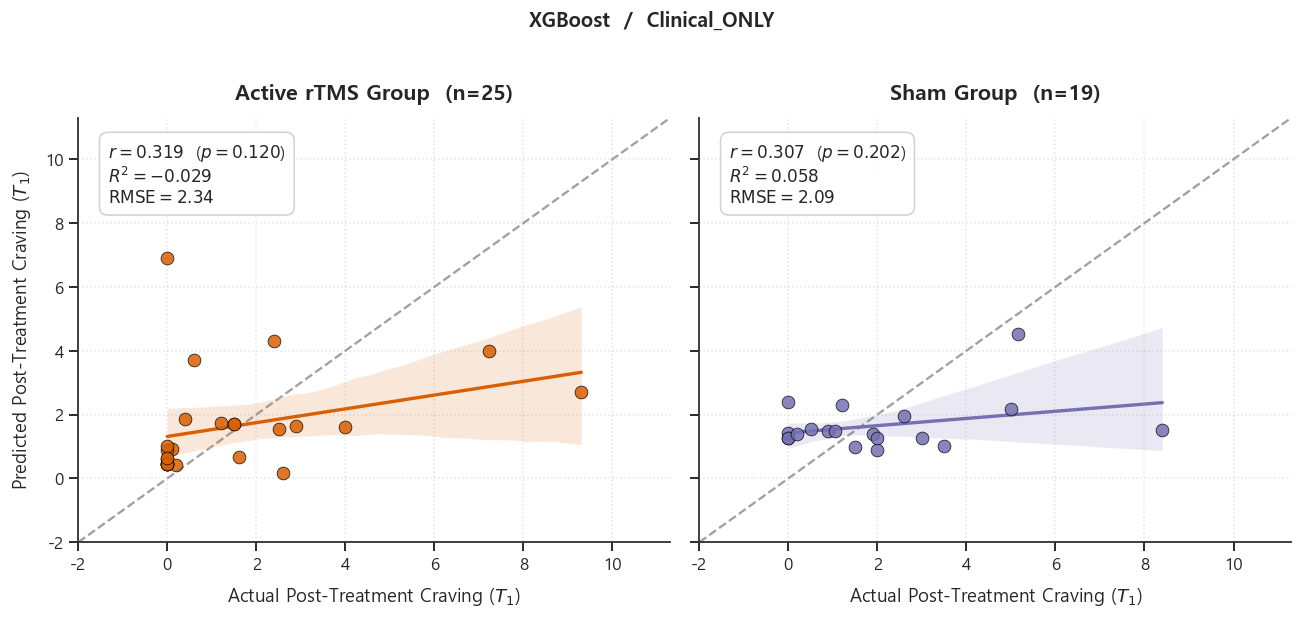

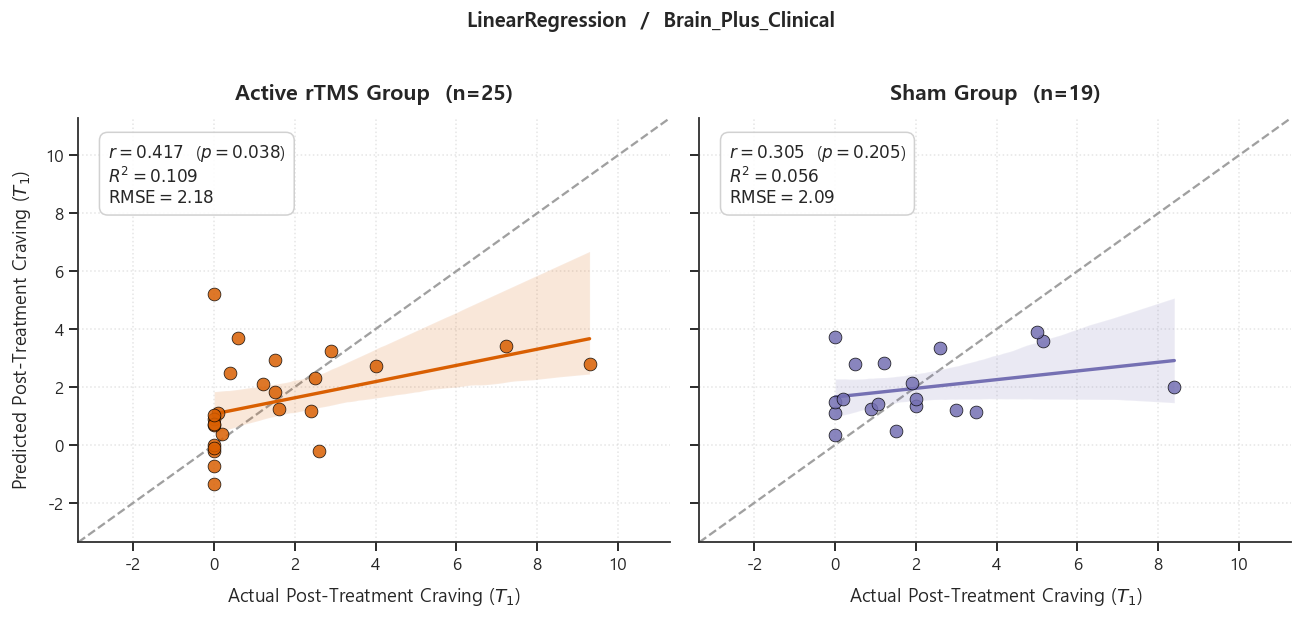

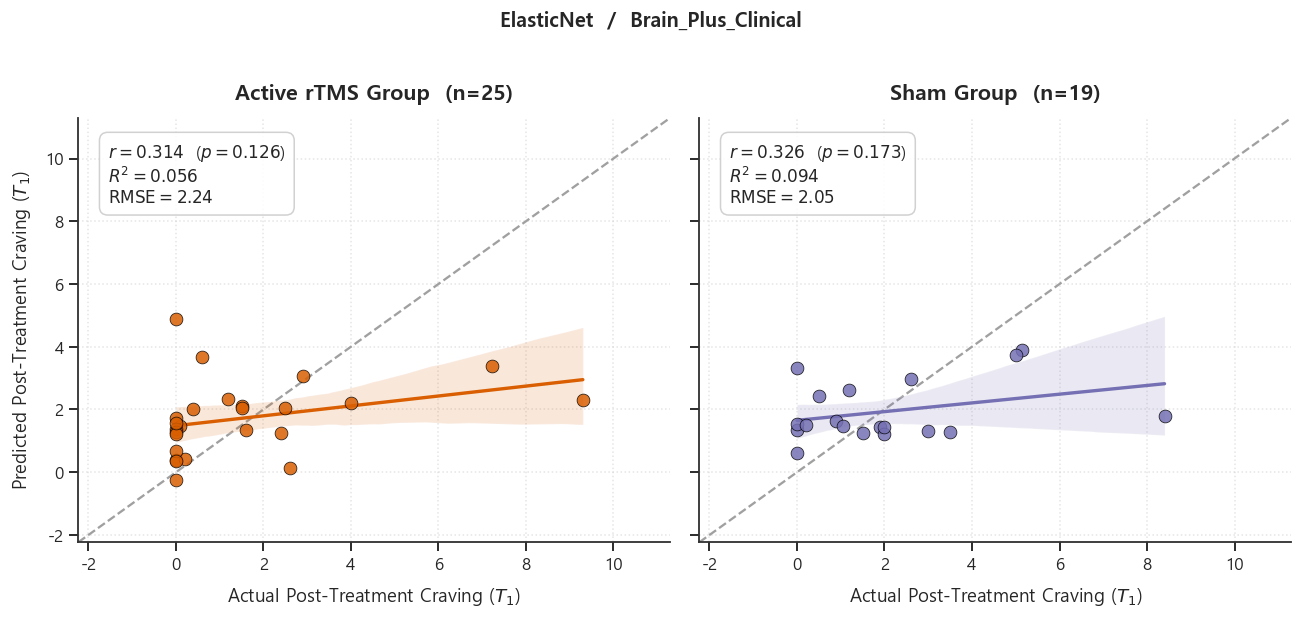

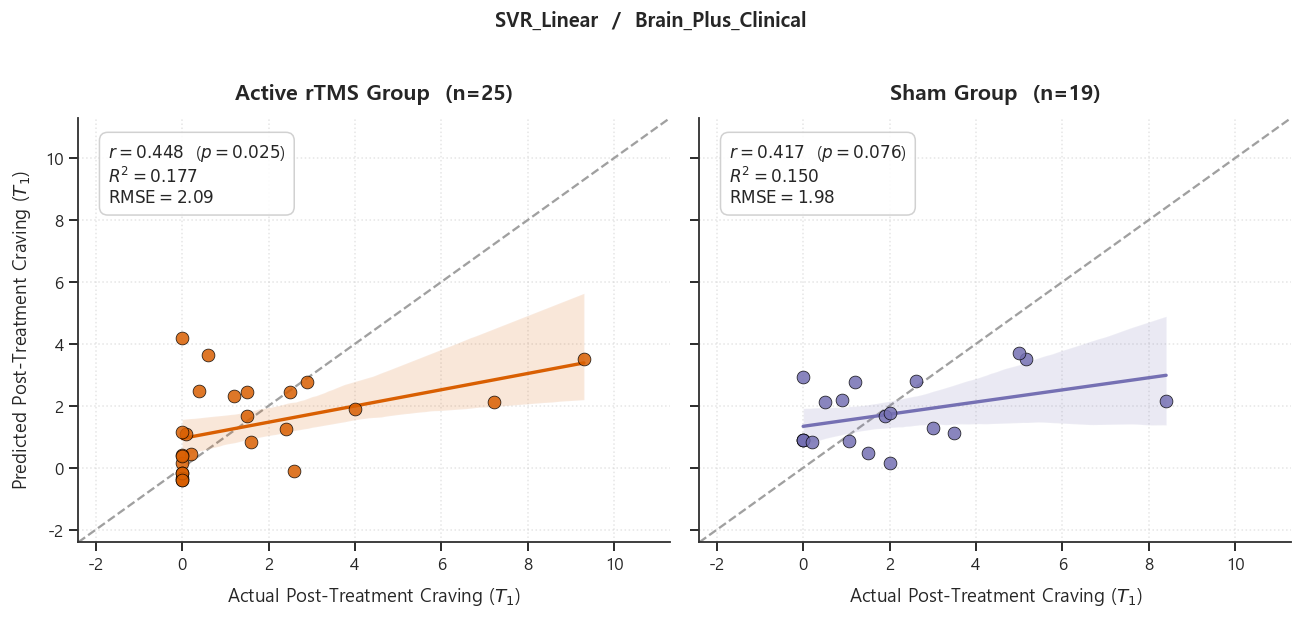

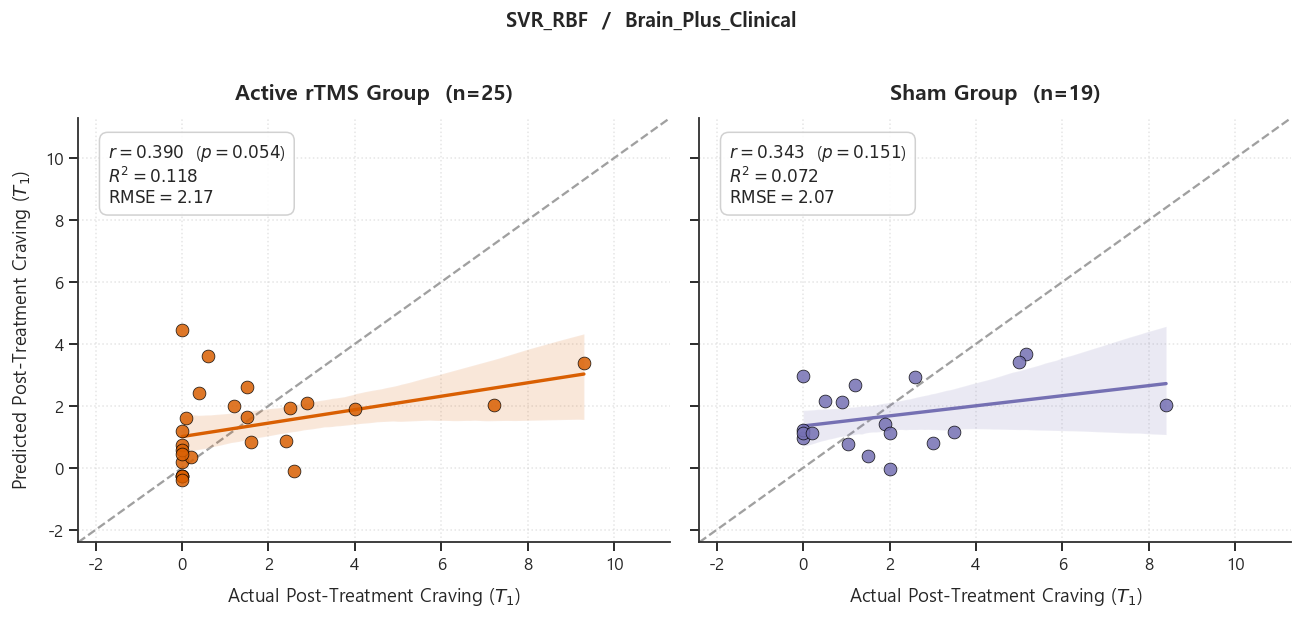

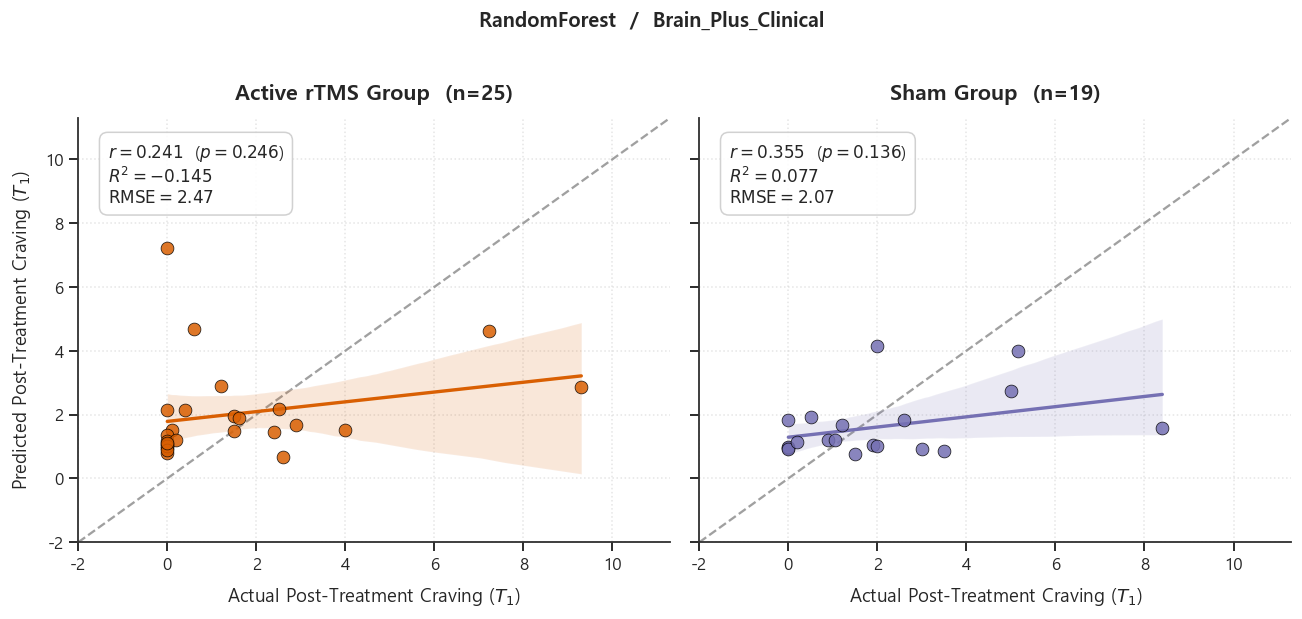

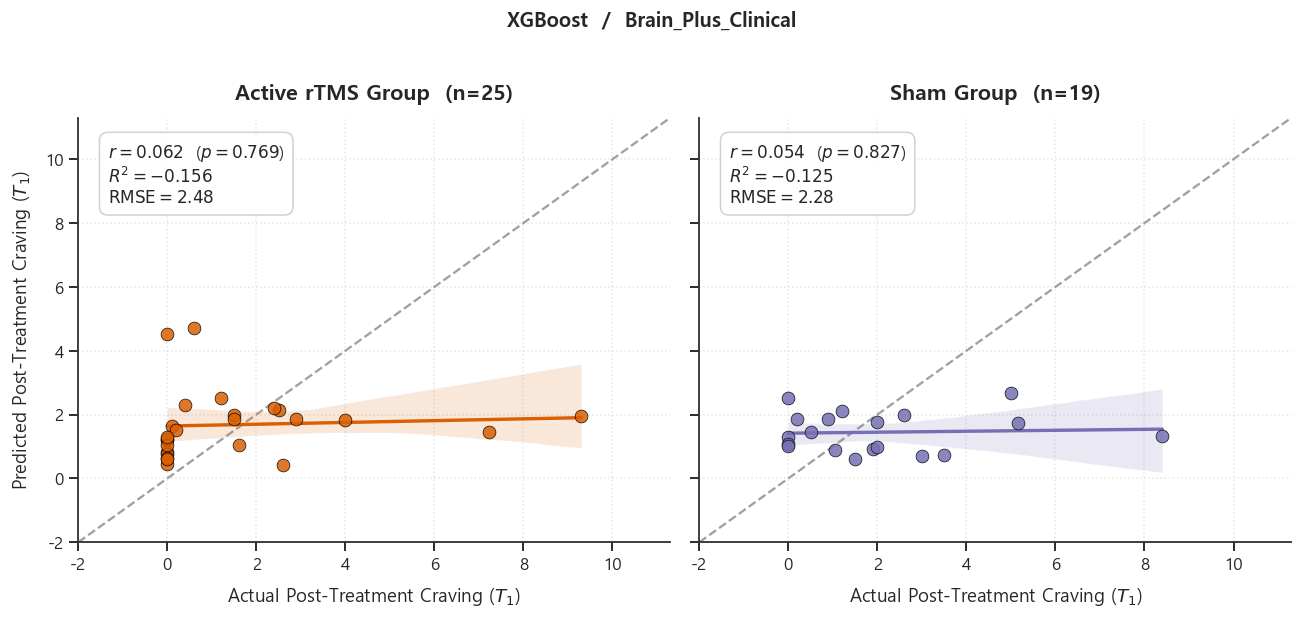

In [9]:
# ==========================================================
# 9. Active vs Sham — 12세트 전부
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'   # Helvetica는 Windows에 없음
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
groups = ['Active rTMS', 'Sham']

for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)

    plot_df = pd.DataFrame({
        'True_Craving': y,
        'Pred_Craving': y_pred,
        'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=110)

    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 2
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 2

    for i, grp in enumerate(groups):
        ax = axes[i]
        sub_df = plot_df[plot_df['Group'] == grp]
        color = palette[grp]

        r, pval = pearsonr(sub_df['True_Craving'], sub_df['Pred_Craving'])
        r2 = r2_score(sub_df['True_Craving'], sub_df['Pred_Craving'])
        rmse = np.sqrt(np.mean((sub_df['True_Craving'] - sub_df['Pred_Craving'])**2))

        ax.plot([min_val, max_val], [min_val, max_val],
                color='#A0A0A0', linestyle='--', linewidth=1.5, zorder=1)

        sns.scatterplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            color=color, s=70, alpha=0.85, edgecolor='black',
            linewidth=0.5, ax=ax, zorder=3
        )

        sns.regplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
        )

        ax.set_title(f'{grp} Group  (n={len(sub_df)})',
                     fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
        if i == 0:
            ax.set_ylabel('Predicted Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)

        stats_text = (f"$r = {r:.3f}$  ($p = {pval:.3f}$)\n"
                      f"$R^2 = {r2:.3f}$\n"
                      f"$\\mathrm{{RMSE}} = {rmse:.2f}$")
        ax.text(
            0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      alpha=0.9, edgecolor='#CCCCCC')
        )

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.grid(True, linestyle=':', alpha=0.5)

    fig.suptitle(f'{name}  /  {dt}', fontsize=13, fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [10]:
# ==========================================================
# 9-1. 산점도 결과 표 — 9번 셀의 r / R2 / RMSE 를 모델별로 정리
#      (그림에 찍힌 값과 같은 숫자다. 12장을 눈으로 비교하기 어려우니 표로 모은다)
# ==========================================================
group = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

rows_scat = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_scat.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

scat = pd.DataFrame(rows_scat)
scat['Data Type'] = pd.Categorical(scat['Data Type'], DATA_TYPES)
scat['Model'] = pd.Categorical(scat['Model'], list(models))

wide = scat.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(scat[scat.Group == g].sort_values('RMSE')[['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 19명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                                Active                        Sham  \
                                       RMSE     R2      r      p   RMSE   
Data Type           Model                                                 
Clinical_ONLY       LinearRegression  2.004  0.246  0.507  0.010  1.989   
                    ElasticNet        2.003  0.247  0.507  0.010  1.988   
                    SVR_Linear        2.055  0.207  0.475  0.016  2.022   
                    SVR_RBF           2.291  0.015  0.358  0.079  2.095   
                    RandomForest      2.261  0.040  0.356  0.081  2.118   
                    XGBoost           2.341 -0.029  0.319  0.120  2.089   
Brain_Plus_Clinical LinearRegression  2.179  0.109  0.417  0.038  2.090   
                    ElasticNet        2.242  0.056  0.314  0.126  2.048   
                    SVR_Linear        2.094  0.177  0.448  0.025  1.983   
                    SVR_RBF           2.168  0.118  0.390  0.054  2.073   
                    RandomForest      2.470 -0.145  0.241  0.246  2.067   
                    XGBoost           2.481 -0.156  0.062  0.769  2.282   

Group                                                      
                                         R2      r      p  
Data Type           Model                                  
Clinical_ONLY       LinearRegression  0.145  0.402  0.088  
                    ElasticNet        0.146  0.402  0.088  
                    SVR_Linear        0.117  0.400  0.090  
                    SVR_RBF           0.052  0.329  0.170  
                    RandomForest      0.031  0.302  0.209  
                    XGBoost           0.058  0.307  0.202  
Brain_Plus_Clinical LinearRegression  0.056  0.305  0.205  
                    ElasticNet        0.094  0.326  0.173  
                    SVR_Linear        0.150  0.417  0.076  
                    SVR_RBF           0.072  0.343  0.151  
                    RandomForest      0.077  0.355  0.136  
                    XGBoost          -0.125  0.054  0.827


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  \
Data Type           Model                                                
Clinical_ONLY       LinearRegression        2.004      1.989     0.507   
                    ElasticNet              2.003      1.988     0.507   
                    SVR_Linear              2.055      2.022     0.475   
                    SVR_RBF                 2.291      2.095     0.358   
                    RandomForest            2.261      2.118     0.356   
                    XGBoost                 2.341      2.089     0.319   
Brain_Plus_Clinical LinearRegression        2.179      2.090     0.417   
                    ElasticNet              2.242      2.048     0.314   
                    SVR_Linear              2.094      1.983     0.448   
                    SVR_RBF                 2.168      2.073     0.390   
                    RandomForest            2.470      2.067     0.241   
                    XGBoost                 2.481      2.282     0.062   

                                      r_Sham  RMSE_diff  
Data Type           Model                                
Clinical_ONLY       LinearRegression   0.402      0.015  
                    ElasticNet         0.402      0.015  
                    SVR_Linear         0.400      0.033  
                    SVR_RBF            0.329      0.196  
                    RandomForest       0.302      0.143  
                    XGBoost            0.307      0.252  
Brain_Plus_Clinical LinearRegression   0.305      0.088  
                    ElasticNet         0.326      0.194  
                    SVR_Linear         0.417      0.111  
                    SVR_RBF            0.343      0.095  
                    RandomForest       0.355      0.402  
                    XGBoost            0.054      0.199


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,RMSE,R2,r,p
0,Clinical_ONLY,ElasticNet,2.003,0.247,0.507,0.010
1,Clinical_ONLY,LinearRegression,2.004,0.246,0.507,0.010
2,Clinical_ONLY,SVR_Linear,2.055,0.207,0.475,0.016
3,Brain_Plus_Clinical,SVR_Linear,2.094,0.177,0.448,0.025
4,Brain_Plus_Clinical,SVR_RBF,2.168,0.118,0.390,0.054



[Sham]


,Data Type,Model,RMSE,R2,r,p
0,Brain_Plus_Clinical,SVR_Linear,1.983,0.150,0.417,0.076
1,Clinical_ONLY,ElasticNet,1.988,0.146,0.402,0.088
2,Clinical_ONLY,LinearRegression,1.989,0.145,0.402,0.088
3,Clinical_ONLY,SVR_Linear,2.022,0.117,0.400,0.090
4,Brain_Plus_Clinical,ElasticNet,2.048,0.094,0.326,0.173


In [11]:
# ==========================================================
# 10. 군간 아티팩트 점검 — vas 분산 / 상관 구조가 다른가
# ==========================================================
from scipy.stats import levene

g = df['treatment_group'].values
vt0, vt1 = df['vas_t0'].values, df['vas_t1'].values

rows = []
for grp, code in [('Active', 2), ('Sham', 1)]:
    m = g == code
    r_raw, p_raw = pearsonr(vt0[m], vt1[m])
    rows.append({
        'group': grp, 'n': m.sum(),
        'vas_t0_mean': vt0[m].mean(), 'vas_t0_SD': vt0[m].std(ddof=1),
        'vas_t1_mean': vt1[m].mean(), 'vas_t1_SD': vt1[m].std(ddof=1),
        'r(t0,t1)': r_raw, 'p': p_raw
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))

# 분산 동일성 (Levene)
for v, nm in [(vt0, 'vas_t0'), (vt1, 'vas_t1')]:
    W, p = levene(v[g == 2], v[g == 1])
    print(f"Levene {nm}: W={W:.3f}, p={p:.3f}")

 group  n  vas_t0_mean  vas_t0_SD  vas_t1_mean  vas_t1_SD  r(t0,t1)     p
Active 25        3.803      3.582        1.521      2.356     0.633 0.001
  Sham 19        2.628      2.903        2.047      2.210     0.491 0.033
Levene vas_t0: W=2.323, p=0.135
Levene vas_t1: W=0.019, p=0.890
